In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

C:\Users\PAVITHRA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import random

random.seed(42)
np.random.seed(42)

In [5]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

C:\Users\PAVITHRA\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PAVITHRA\.cache\huggingface\hub\datasets--stanfordnlp--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 224068.11 examp

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [7]:
dataset.keys()

dict_keys(['train', 'test', 'unsupervised'])

In [8]:
dataset["train"]
dataset["test"]

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [9]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [10]:
dataset["train"].features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

In [11]:
print(dataset["train"][0]["text"])
print(dataset["train"][0]["label"])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [12]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [13]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [14]:
train_df.shape

(25000, 2)

In [15]:
test_df.shape

(25000, 2)

In [16]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [17]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [18]:
train_df.duplicated().sum()

np.int64(96)

In [19]:
test_df.duplicated().sum()

np.int64(199)

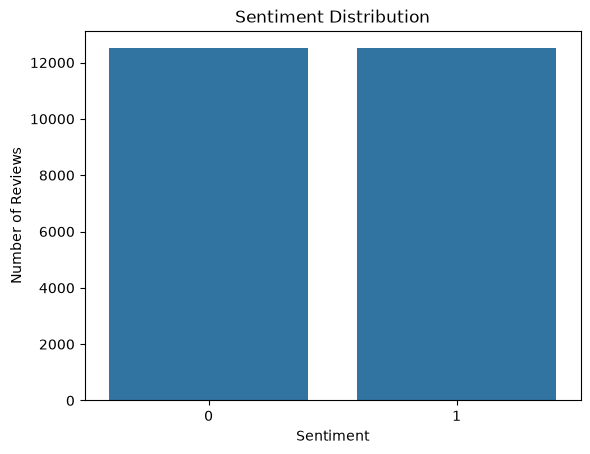

In [20]:
sns.countplot(data=train_df, x="label")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
train_df["sentiment"] = train_df["label"].map({
    0: "Negative",
    1: "Positive"
})

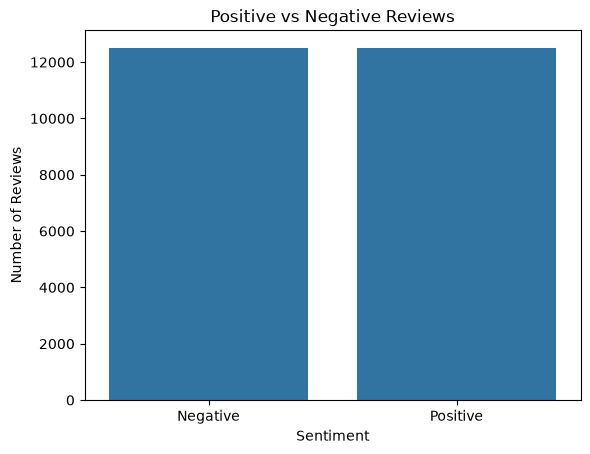

In [22]:
sns.countplot(data=train_df, x="sentiment")

plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [23]:
train_df["review_length"] = train_df["text"].str.len()

In [24]:
train_df["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

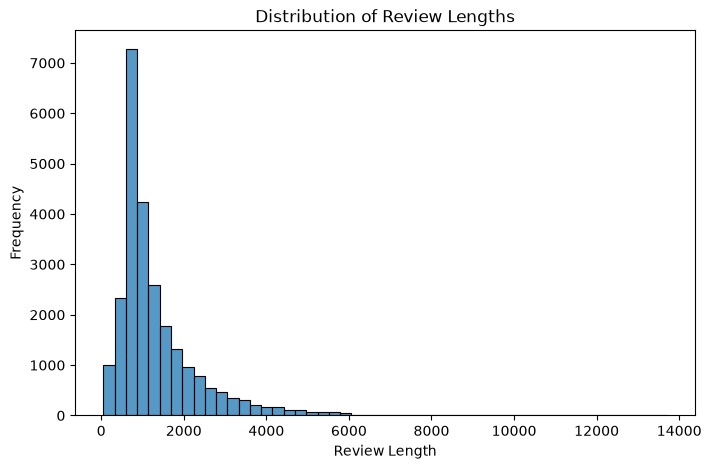

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["review_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

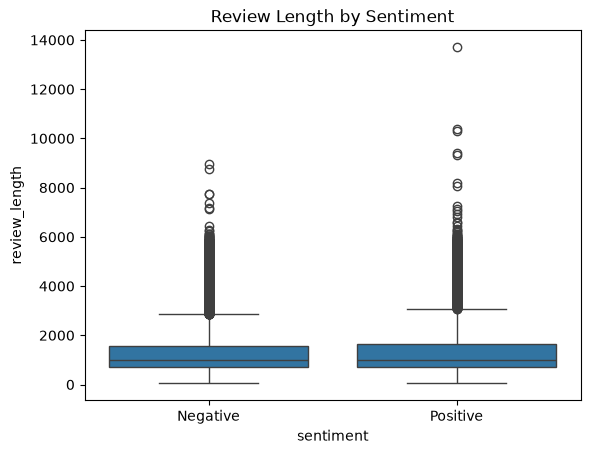

In [26]:
sns.boxplot(
    data=train_df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")
plt.show()

In [27]:
train_df[train_df["label"] == 1]["text"].head()

12500    Zentropa has much in common with The Third Man...
12501    Zentropa is the most original movie I've seen ...
12502    Lars Von Trier is never backward in trying out...
12503    *Contains spoilers due to me having to describ...
12504    That was the first thing that sprang to mind a...
Name: text, dtype: str

In [28]:
train_df[train_df["label"] == 0]["text"].head()

0    I rented I AM CURIOUS-YELLOW from my video sto...
1    "I Am Curious: Yellow" is a risible and preten...
2    If only to avoid making this type of film in t...
3    This film was probably inspired by Godard's Ma...
4    Oh, brother...after hearing about this ridicul...
Name: text, dtype: str

In [29]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

In [32]:
X_train = tfidf.fit_transform(train_df["text"])

In [33]:
X_val = tfidf.transform(val_df["text"])
X_test = tfidf.transform(test_df["text"])

In [34]:
y_train = train_df["label"]
y_val = val_df["label"]
y_test = test_df["label"]

In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [36]:
y_val_pred = lr_model.predict(X_val)

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [38]:
accuracy = accuracy_score(y_val, y_val_pred)

precision = precision_score(y_val, y_val_pred)

recall = recall_score(y_val, y_val_pred)

f1 = f1_score(y_val, y_val_pred)

In [39]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8972
Precision: 0.8915615141955836
Recall: 0.9044
F1 Score: 0.8979348689436061


In [40]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      2500
           1       0.89      0.90      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



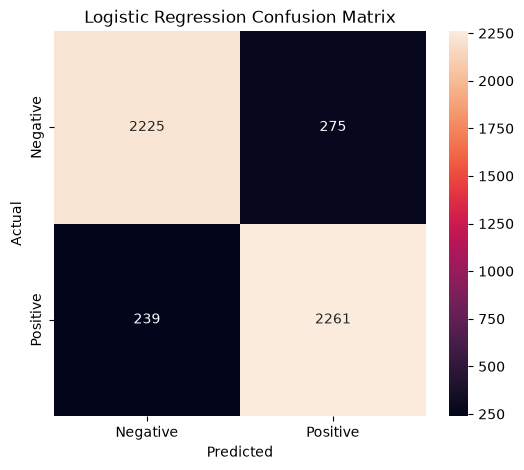

In [41]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [43]:
import os

os.makedirs("plots", exist_ok=True)

In [44]:
plt.savefig("plots/baseline_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [45]:
y_val_prob = lr_model.predict_proba(X_val)[:, 1]

In [46]:
roc_auc = roc_auc_score(y_val, y_val_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.96082624


In [49]:
import os

os.makedirs("models", exist_ok=True)

In [50]:
import joblib

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

joblib.dump(
    lr_model,
    "models/logistic_regression.pkl"
)

['models/logistic_regression.pkl']

In [51]:
import joblib

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

joblib.dump(
    lr_model,
    "models/logistic_regression.pkl"
)

['models/logistic_regression.pkl']

In [52]:
import os

print(os.getcwd())

C:\Users\PAVITHRA\Documents\HVired1\customer-review-sentiment-analysis


In [53]:
print(os.listdir())

['.ipynb_checkpoints', '01_data_loading.ipynb', 'models', 'plots']


In [54]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

In [55]:
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(lr_model, "models/logistic_regression.pkl")

['models/logistic_regression.pkl']

In [56]:
plt.savefig("plots/baseline_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [57]:
import os

print(os.listdir("models"))

['logistic_regression.pkl', 'tfidf_vectorizer.pkl']


In [58]:
y_val_pred = lr_model.predict(X_val)

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

y_val_prob = lr_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_val_prob)

print("Baseline Model Performance")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Baseline Model Performance
--------------------------
Accuracy : 0.8972
Precision: 0.8915615141955836
Recall   : 0.9044
F1 Score : 0.8979348689436061
ROC-AUC  : 0.96082624


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

y_val_prob = lr_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_val_prob)

print("Baseline Model Performance")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Baseline Model Performance
--------------------------
Accuracy : 0.8972
Precision: 0.8915615141955836
Recall   : 0.9044
F1 Score : 0.8979348689436061
ROC-AUC  : 0.96082624


In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      2500
    Positive       0.89      0.90      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



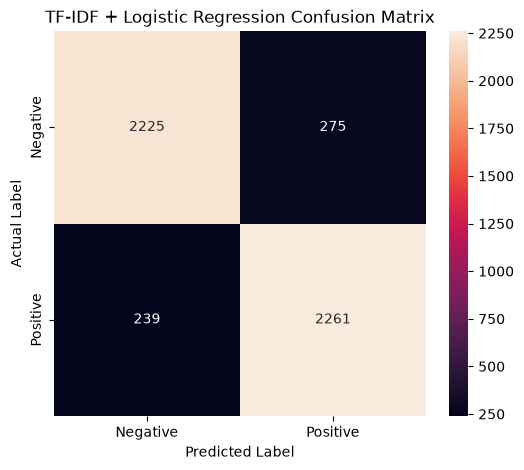

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("TF-IDF + Logistic Regression Confusion Matrix")

plt.show()

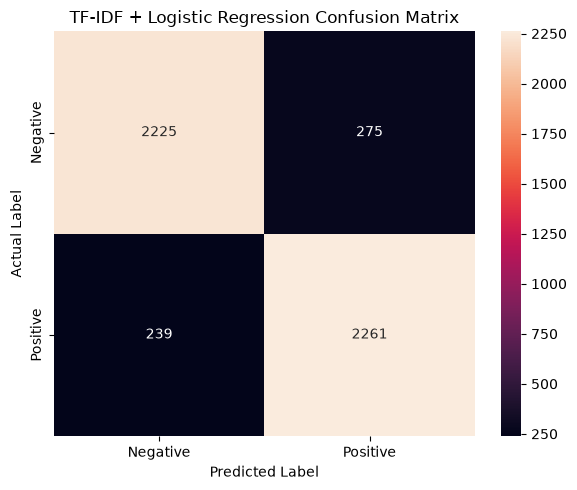

In [63]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("TF-IDF + Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "plots/baseline_confusion_matrix.png",
    dpi=300
)

plt.show()

In [64]:
print(os.listdir("plots"))

['baseline_confusion_matrix.png']


In [65]:
error_df = val_df.copy()

error_df["predicted"] = y_val_pred

error_df["actual_sentiment"] = error_df["label"].map({
    0: "Negative",
    1: "Positive"
})

error_df["predicted_sentiment"] = error_df["predicted"].map({
    0: "Negative",
    1: "Positive"
})

In [66]:
errors = error_df[
    error_df["label"] != error_df["predicted"]
]

In [67]:
print("Number of incorrect predictions:", len(errors))

Number of incorrect predictions: 514


In [68]:
errors[
    ["text", "actual_sentiment", "predicted_sentiment"]
].head(10)

,text,actual_sentiment,predicted_sentiment
23366,"Yowsa! If you REALLY want some ACTION, check o...",Positive,Negative
13204,I rated this a ten just because I find it so i...,Positive,Negative
5343,"Chris, an adopted son of a moral family, a los...",Negative,Positive
21084,"A long time ago, I watched this movie from the...",Positive,Negative
9925,This movie tackles child abduction from the po...,Negative,Positive
74,"I'm studying Catalan, and was delighted to fin...",Negative,Positive
3726,I saw this film over the weekend and while I w...,Negative,Positive
21988,I waited a while to post a review of this docu...,Positive,Negative
13551,"I agree with all the accolades, I went through...",Positive,Negative
22485,"Any story comprises a premise, characters and ...",Positive,Negative


In [69]:
errors[
    ["text", "actual_sentiment", "predicted_sentiment"]
].head(20).to_csv(
    "models/baseline_error_cases.csv",
    index=False
)